# Marlim 3 - Tutoriais em Python

# Análise nodal do escoamento

CVPO - 12/2024

Neste notebook, montaremos um caso base em regime permanente no [Marlim 3](https://github.com/petrobras/marlim3) e realizaremos diversas simulações, variando algumas propriedades do sistema, para ilustrar os conceitos básicos de [análise nodal](https://petrowiki.spe.org/Nodal_analysis) do escoamento.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import marlim3
import copy

## Introdução

Um dos principais objetivos da disciplina de Elevação e Escoamento (EE) é prever a queda de pressão ao longo do trajeto do fluido, desde o fundo do poço até a plataforma. Na mecânica dos fluidos de engenharia, essa queda de pressão é conhecida como perda de carga. Esse fenômeno está diretamente relacionado às características do escoamento na tubulação, como propriedades dos fluidos, geometria da linha, entre outros fatores, e pode ser modelado por meio de simuladores de escoamento multifásico, como o [**Marlim 3**](https://github.com/petrobras/marlim3). Como a pressão de chegada na plataforma é previamente definida para atender às demandas do processamento primário da planta de superfície, a variável de interesse torna-se a pressão no fundo do poço. Essa pressão deve ser suficiente para superar a perda de carga e garantir que a pressão especificada seja alcançada na plataforma.


### IPR: Inflow Performance Relationship

Mas, o que ocorre antes do fundo do poço? O fluido provém do reservatório de petróleo, onde a força motriz para o escoamento é o diferencial de pressão entre a pressão do reservatório (conhecida como pressão estática, $P_e$) e a pressão no fundo do poço ($P_{wf}$). Esse fenômeno é modelado na disciplina de Reservatórios (RES) e depende das características do escoamento no meio poroso do reservatório.

Como, então, se dá a integração entre as disciplinas de RES e EE para a modelagem do sistema? RES tipicamente fornece à EE uma curva que relaciona a vazão produzida com a pressão estática e a pressão no fundo do poço. Essa curva, conhecida como IPR (Inflow Performance Relationship), é utilizada como condição de contorno nas simulações de escoamento na tubulação. Também chamada de curva de pressão disponível, a IPR relaciona a pressão no fundo do poço com a vazão produzida em condições de superfície. Ela é uma representação da produtividade do reservatório e é função das características do meio poroso que o compõe.

O modelo de IPR mais simples é o linear:

$$Q = \texttt{IP}(P_e-P_{wf}),$$

onde $Q$ é a vazão em condições de superfície, $P_e$ é a pressão estática do reservatório e $P_{wf}$ é a pressão no fundo do poço.

O parâmetro $\texttt{IP}$, conhecido como índice de produtividade, representa a constante de proporcionalidade entre a vazão produzida e o diferencial de pressão entre o reservatório e o fundo do poço. Esse diferencial é interpretado como a força motriz para o escoamento no trecho em questão. O modelo linear é particularmente útil para descrever fluxos monofásicos no meio poroso. No entanto, quando a pressão está abaixo da pressão de saturação e gás começa a ser liberado já no meio poroso, é recomendável adotar outros modelos, como o modelo de Vogel, também disponível no [**Marlim 3**](https://github.com/petrobras/marlim3).

### TPR: Tubing Performance Relationship

A curva IPR, fornecida pela disciplina de RES, descreve a relação entre a vazão produzida e o diferencial de pressão entre o reservatório e o fundo do poço. De forma análoga, a EE utiliza simulações de escoamento multifásico para gerar uma curva chamada TPR (Tubing Performance Relationship), ou curva de pressão requerida, que relaciona a mesma vazão produzida com o diferencial de pressão entre o fundo do poço e a plataforma. O ponto de interseção entre as duas curvas representa a vazão e a pressão que o sistema efetivamente produzirá quando em equilíbrio, em regime permanente.

Essa abordagem é conhecida como análise nodal, pois determina o estado do sistema no ponto de interseção das curvas de pressão em um nó específico da linha — nesse caso, o fundo do poço.

Neste notebook, exploraremos como realizar a análise nodal utilizando o [**Marlim 3**](https://github.com/petrobras/marlim3).

## Montagem do caso base

Preencheremos um objeto `Tramo` do [**Marlim 3**](https://petrobrasbr.sharepoint.com/teams/Marlim3) para o caso base:

In [2]:
caso_base = marlim3.Tramo()

### Fluido de produção

Definimos um fluido de produção do tipo [*black oil*](https://wiki.whitson.com/bopvt/bot/):

In [3]:
fluido = {
    "id": 0,
    "api": 20,
    "rgo": 50,
    "densidadeGas": 0.7,
    "bsw": 0.0,
}

caso_base.fluidosProducao = [fluido]

O [**Marlim 3**](https://github.com/petrobras/marlim3) oferece outras possibilidades de modelagem de fluido: tabelas *flash* e modelos composicionais.

### Formação

No [**Marlim 3**](https://github.com/petrobras/marlim3), é possível adicionar uma lista de informações térmicas relacionadas à litologia de rochas, que podem ser utilizadas para modelar as trocas de calor entre o poço e a formação. Abaixo, incluímos um exemplo de uma rocha típica com tempo de produção de um ano. Esse parâmetro é relevante porque, à medida que o poço produz, a rocha ao redor é gradualmente influenciada termicamente pelo fluido em escoamento.

In [4]:
rocha = {
    "id": 0,
    "condutividade": 2.5, # W/(m.degC)
    "calorEspecifico": 1e3, # J/(kg.degC)
    "massaEspecifica": 2.5e3 # kg/m3
}

caso_base.configuracaoInicial['Formacao'] = {
    'Propriedades': [rocha],
    'TempoProducao': 365 #dias 
}

### Tubulação

#### Materiais

Abaixo definimos dois materiais a serem utilizados para compor a tubulação: aço e um material isolante.

In [5]:
aco = {
    "id": 0,
    "rotulo": "Aço",
    "tipo": 0, # sólido
    "condutividade": 58, #W/m.K
    "calorEspecifico": 480, #J/kg.K
    "rho": 7850, #kg/m3
}

fluido_completacao = {
    "id": 1,
    "rotulo": "Fluido de completação",
    "tipo": 2 #água
}

cimento = {
    "id": 2,
    "rotulo": "Cimento",
    "tipo": 0, #sólido
    "condutividade":0.6,
    "calorEspecifico":1000.0,
    "rho":500.0
}

isolante = {
    "id": 3,
    "rotulo": "Isolante",
    "tipo": 0, # sólido
    "condutividade": 0.12, #W/m.K
    "calorEspecifico": 1214, #J/kg.K
    "rho": 510, #kg/m3
}

caso_base.material = [aco, fluido_completacao, cimento, isolante]

#### Seções transversais

O sistema de produção é constituído por várias camadas que comporão as diferentes seções transversais.

In [6]:
camada_aco_interna = {
    "rotulo": "Camada de aço interna",
    "idMaterial": 0, #id do material definido anteriormente
    "tipoMedicaoCamada": "ESPESSURA",
    "espessura": 0.0254*0.25, #m
}

camada_fluido_completacao = {
    "rotulo": "Camada de fluido de completação",
    "idMaterial": 1, #id do material definido anteriormente
    "tipoMedicaoCamada": "ESPESSURA",
    "espessura": 0.0254*3, #m
}

camada_aco_revestimento = {
    "rotulo": "Camada de aço do revestimento",
    "idMaterial": 0, #id do material definido anteriormente
    "tipoMedicaoCamada": "ESPESSURA",
    "espessura": 0.0254*0.5, #m
}

camada_cimento = {
    "rotulo": "Camada de cimento",
    "idMaterial": 2, #id do material definido anteriormente
    "tipoMedicaoCamada": "ESPESSURA",
    "espessura": 0.0254*3, #m
}

camada_isolante = {
    "rotulo": "Camada de isolante",
    "idMaterial": 3, #id do material definido anteriormente
    "tipoMedicaoCamada": "ESPESSURA",
    "espessura": 0.0254*2, #m
}

Duas seções transversais são definidas no sistema: uma correspondente ao poço, composta apenas pela camada de aço, e outra referente à flowline e ao riser, formada por duas camadas — aço e material isolante. Ambas as seções possuem o mesmo diâmetro interno ($8$") e a mesma rugosidade absoluta ($0.183$ mm).

In [7]:
secao_poco = {
    "id": 0,
    "rotulo": "Corte do poço",
    "diametroInterno": 8*0.0254, #m
    "rugosidade": 0.183e-3, #m
    "camadas": [camada_aco_interna, camada_fluido_completacao, camada_aco_revestimento, camada_cimento]
}

secao_flowline_riser = {
    "id": 1,
    "rotulo": "Corte da flowline+riser",
    "diametroInterno": 8*0.0254, #m
    "rugosidade": 0.183e-3, #m
    "camadas": [camada_aco_interna, camada_isolante]
}

Definidas as duas seções, podemos adicioná-las ao atributo `secaoTransversal`:

In [8]:
caso_base.secaoTransversal = [secao_poco, secao_flowline_riser]

#### Dutos

No [**Marlim 3**](https://github.com/petrobras/marlim3), a tubulação é dividida em trechos denominados dutos. Neste caso, serão três porções: poço, flowline e riser. Cada uma delas terá uma extensão de $1000$ m e será subdividida em 10 células para a discretização.

##### Poço

Um comportamento típico do gradiente geotérmico em poços apresenta uma diminuição mais acentuada da temperatura na porção final. Para representar esse comportamento, definimos as temperaturas em três pontos ao longo do comprimento relativo do duto: $90$°C no início, $50$°C em 80% do comprimento, e $4$°C ao final, correspondendo à temperatura do leito marinho.

In [9]:
ncel = 10

comprimento_total = 1000 #m

discretizacao = {
    "nCelulas": ncel,
    "comprimento": comprimento_total/ncel #m
}

condicoes_formacao = {
          "compInter": [0, 0.8, 1],
          "tempExterna": [90, 50, 4], #degC
}

coluna = {
        "id": 0,
        "rotulo": "Poço",
        "idCorte": 0, #id da seção transversal de poço definida anteriormente
        "idFormacao": 0, #id da formação definida anteriormente
        "angulo": np.pi/2, #rad
        "discretizacao": [discretizacao], #discretização definida logo acima
        "condicoesIniciais": condicoes_formacao #condições definidas logo acima
} 

##### Flowline

Na flowline, o ambiente externo é especificado como água do mar. Para esse caso, é necessário definir a temperatura externa e a velocidade externa:

In [10]:
ncel = 10

comprimento_total = 1000 #m

discretizacao = {
    "nCelulas": ncel,
    "comprimento": comprimento_total/ncel #m
}

condicoes_leito_marinho = {
          "compInter": [0, 1],
          "tempExterna": [4, 4], #degC
          "velExterna": [0.1, 0.1], #m/s

}

linha = {
        "id": 1,
        "rotulo": "Flowline",
        "idCorte": 1, #id da seção transversal de flowline+riser definida anteriormente
        "ambienteExterno": 1, #água do mar
        "angulo": 0, #rad
        "discretizacao": [discretizacao], #discretização definida logo acima
        "condicoesIniciais": condicoes_leito_marinho #condições definidas logo acima
}

##### Riser

No riser, o ambiente externo também é a água do mar, mas dessa vez há um gradiente de temperatura e velocidade do leito marinho até a superfície:

In [11]:
ncel = 10

comprimento_total = 1000 #m

discretizacao = {
    "nCelulas": ncel,
    "comprimento": comprimento_total/ncel #m
}

condicoes_mar_subida = {
          "compInter": [0, 1],
          "tempExterna": [4, 20], #degC
          "velExterna": [0.1, 1], #m/s

}

riser = {
        "id": 2,
        "rotulo": "Riser",
        "idCorte": 1, #id da seção transversal de flowline+riser definida anteriormente
        "ambienteExterno": 1, #água do mar
        "angulo": np.pi/2, #rad
        "discretizacao": [discretizacao], #discretização definida logo acima
        "condicoesIniciais": condicoes_mar_subida #condições definidas logo acima
}

Definidos os três dutos, podemos adicioná-los ao atributo `dutosProducao`:

In [12]:
caso_base.dutosProducao = [coluna, linha, riser]

Visualizando a geometria:

In [13]:
caso_base.plotar_geometria();

### Master 1

Para indicar a posição da Árvore de Natal Molhada (ANM), será definido um objeto do tipo `master1`. Esse objeto representa a válvula responsável por controlar a produção na ANM. No regime permanente, a master1 não tem efeito além dessa indicação da posição da ANM, então a única propriedade preenchida será o `comprimentoMedido`:

In [14]:
master1 = {'comprimentoMedido': 1000} #m
caso_base.master1 = master1

Em uma simulação transiente, seria importante definir a abertura da válvula, mesmo que permanecesse constante ao longo do tempo.

### Condições de contorno

As condições de contorno (CC) no nosso caso são $1$) IPR a montante e $2$) pressão a jusante.

#### CC1: IPR a montante

A CC $1$ deve ser definida por meio de um objeto `ipr` colocado bem no começo da tubulação (no caso abaixo, $0.1$ m de comprimento medido).

In [15]:
cc_mon =  {'id': 0,
           'tipoIPR': 0, #linear
           'indFluidoPro': 0, # id do fluido definido anteriormente
           'comprimentoMedido': 0.1, #m
           'tempoPressaoEstatica': [0], #s
           'pressaoEstatica': [150], #kgf/cm2
           'tempoTemperaturas': [0], #s
           'temperaturas': [90],  #degC
           'tempoip': [0], #s
           'ip': [200], # (sm3/d)/(kgf/cm2)
           'tempoii': [0], #s
           'ii': [200], # (sm3/d)/(kgf/cm2)
          }

caso_base.ipr = [cc_mon]

O índice de injetividade, `ii`, é importante de definir para um possível caso de fluxo reverso (em que o poço "bebe").

#### CC2: pressão a jusante

A CC $2$ deve ser definida por meio do campo `separador`.

In [16]:
cc_jus = {
    "tempo": [0], #s
    "pressao": [10], #kgf/cm2
}

caso_base.separador = cc_jus

### Especificação da saída da simulação

Podemos escolher quais variáveis de saída (no nosso caso, perfis, ou variações ao longo da linha) serão informadas como resultados da simulação. 

Abaixo, especificamos pressão, temperatura, *holdup* de líquido, arranjo de fases (padrão de escoamento), parcelas de fricção e hidrostática da perda de carga e vazão de líquido.

In [17]:
vars_saida_list = ["pressao", 
                   "temperatura", 
                   "holdup", 
                   "arra", 
                   "fric", 
                   "hidro",
                   "QLstd"
                  ] 

vars_saida = {"tempo": [0]} | {var: True for var in vars_saida_list}

caso_base.perfilProducao = vars_saida

## Executando simulações e analisando resultados

### Simulação base

Rodemos uma simulação para o caso base:

In [18]:
caso_base.simular()

*******************************************************************************
                                  UFA!!!!!!!!                                  
      So nos curamos de um sofrimento depois de o haver suportado ate o fim.    
                                Marcel Proust no CrossFit                               
*******************************************************************************
ARQUIVO DE LOG: simulacao.log



In [19]:
caso_base.resultados['perfilProducao']

Comprimento (m) Fronteira F  Comprimento (m) Centro Volume C  \
Tempo (s)                                                                    
0         0                             0                               50   
          1                           100                              150   
          2                           200                              250   
          3                           300                              350   
          4                           400                              450   
          5                           500                              550   
          6                           600                              650   
          7                           700                              750   
          8                           800                              850   
          9                           900                              950   
          10                         1000                             1050   
          11                         1100                             1150   
          12                         1200                             1250   
          13                         1300                             1350   
          14                         1400                             1450   
          15                         1500                             1550   
          16                         1600                             1650   
          17                         1700                             1750   
          18                         1800                             1850   
          19                         1900                             1950   
          20                         2000                             2050   
          21                         2100                             2150   
          22                         2200                             2250   
          23                         2300                             2350   
          24                         2400                             2450   
          25                         2500                             2550   
          26                         2600                             2650   
          27                         2700                             2750   
          28                         2800                             2850   
          29                         2900                             2950   

              Pressao (kgf/cm2) C  Temperatura (C) C  Holdup de liquido (-) C  \
Tempo (s)                                                                       
0         0            134.517580          90.000000                 0.927141   
          1            126.295724          89.773513                 0.931103   
          2            118.063065          89.520236                 0.912146   
          3            109.958168          89.230408                 0.891711   
          4            101.997321          88.903826                 0.869587   
          5             94.198486          88.540367                 0.845652   
          6             86.580571          88.140017                 0.819868   
          7             79.163673          87.702864                 0.792050   
          8             71.969137          87.229051                 0.762134   
          9             65.018572          86.674790                 0.730141   
          10            61.540570          85.996276                 0.688896   
          11            61.412283          85.756800                 0.677722   
          12            61.284748          85.517941                 0.677245   
          13            61.157012          85.279717                 0.676784   
          14            61.029073          85.042104                 0.676305   
          15            60.900932          84.805103                 0.675839   
          16            60.772584          84.568711       

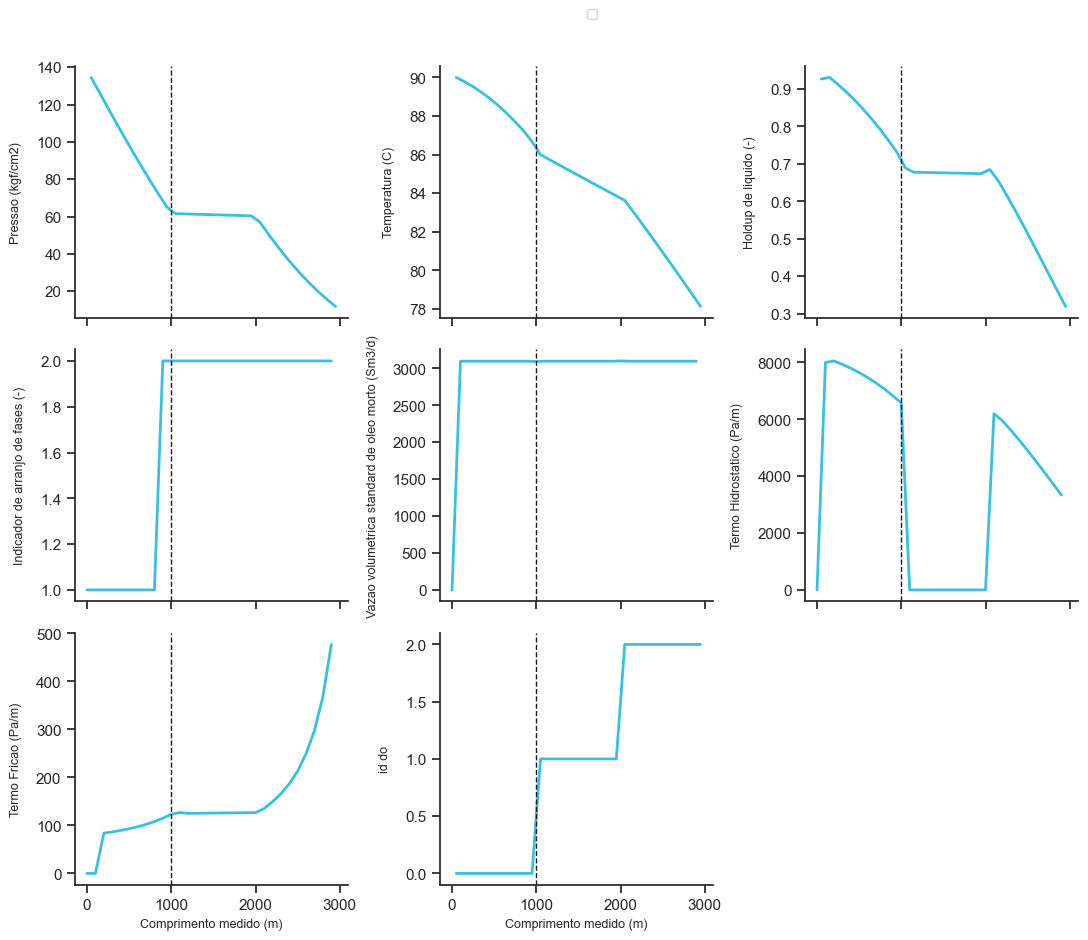

In [20]:
caso_base.plotar_perfis(indicar_anm=True);

Nos gráficos de perfis acima, a linha vertical tracejada representa a posição da ANM. Observe a figura e analise o comportamento de cada uma das variáveis. Você consegue interpretar as mudanças de comportamento ao longo dos três trechos (poço, flowline e riser), cada um com extensão de 1000 metros?

### Obtendo curvas TPR

A solução obtida acima corresponde à vazão de equilíbrio da IPR, na qual a pressão disponível no fundo do poço se iguala à pressão necessária para superar a perda de carga e atingir o separador com a pressão especificada na CC2.

Para gerar uma curva TPR, é necessário remover a condição de contorno associada à IPR (desativando-a por meio do booleano `ativo`) e adicionar uma nova condição de contorno que corresponda à vazão de líquido especificada na entrada:

In [21]:
caso_base.ipr[0]['ativo'] = False

nova_cc_mon = {
    "id": 0,
    "indiFluidoPro": 0, #id do fluido definido anteriormente
    "comprimentoMedido": 0.1, #m
    "tempo": [0], #s
    "temperatura": [90] #degC
} 

caso_base.fonteLiquido = [nova_cc_mon]

Note que não definimos a `vazaoLiquido` na nova condição de contorno (CC). Ela será adicionada no laço `for` abaixo, sendo configurada trinta vezes, com valores diferentes a cada iteração. Isso resultará em trinta simulações, cada uma representando uma condição de vazão distinta. Para cada vazão, será calculada uma pressão associada no fundo do poço ($P_{wf}$). As combinações de $Q$ (vazão) e $P_{wf}$ obtidas constituem os pontos que formam a curva TPR.

In [22]:
%%time

vazoes_eixo_x = np.linspace(10,8000,30)  #sm3/d
casos = []

# rodando uma simulação para cada vazão
for vazao in vazoes_eixo_x:
    casos.append(copy.deepcopy(caso_base))
    casos[-1].configuracaoInicial['saidaClassica'] = False
    casos[-1].fonteLiquido[0]['vazaoLiquido'] = [vazao]
    casos[-1].simular()

# obtendo as pressoes de fundo a partir dos resultados dos vários casos
pressoes_fundo_tpr = np.array([casos[i].resultados['perfilProducao'].iloc[:,2][0,0] for i in range(len(casos))])

# reativando a CC IPR para o caso base
caso_base.ipr[0]['ativo'] = True
caso_base.fonteLiquido[0]['ativo'] = False































CPU times: total: 797 ms
Wall time: 1min 9s


### Plotando IPR e TPR

Vamos enfim visualizar as curvas!

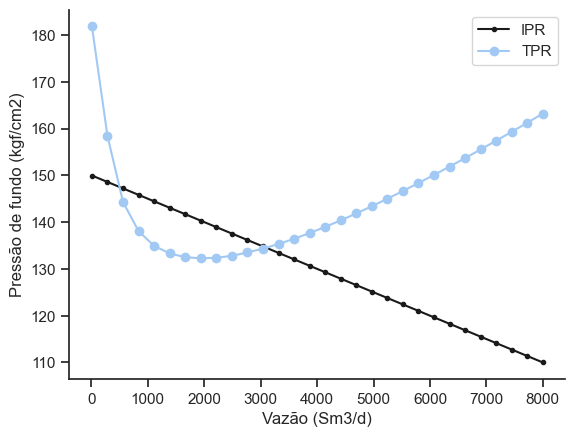

In [23]:
fig, ax = plt.subplots()

# função anônima representando a pressão do fundo do poço da IPR
Pwf_ipr = lambda Pe, Q, IP: Pe - Q/IP

# propriedades da IPR
Pe = caso_base.ipr[0]['pressaoEstatica'][0]
IP = caso_base.ipr[0]['ip'][0]

# calculando ipr!
pressoes_fundo_ipr = Pwf_ipr(Pe, vazoes_eixo_x, IP)

# plotando IPR
ax.plot(vazoes_eixo_x, pressoes_fundo_ipr, label='IPR', marker='.', c='k')

# plotando TPR
ax.plot(vazoes_eixo_x, pressoes_fundo_tpr, label=f'TPR', marker='o')

ax.set_xlabel('Vazão (Sm3/d)')
ax.set_ylabel('Pressão de fundo (kgf/cm2)');
ax.legend();

Um dos pontos de interseção entre as curvas representa a vazão obtida na simulação base, $Q = 3061$ sm$^3$/d, na qual a IPR foi utilizada como condição de contorno (CC).

E quanto ao outro ponto de interseção? Ele corresponde a um ponto de equilíbrio instável. Isso ocorre quando a curva TPR cruza a IPR de cima para baixo. Naturalmente, os simuladores tendem a convergir para a solução estável, que funciona como um atrator numérico do sistema.

Por fim, uma última questão sobre a figura: por que há uma mudança no sentido de crescimento da função na TPR? Inicialmente, as pressões de fundo reduzem com o aumento da vazão, mas, a partir de determinado ponto, começam a aumentar. Esse comportamento está relacionado à natureza multifásica do escoamento. Em baixas vazões, o gás não consegue arrastar o líquido eficientemente, o que resulta em um aumento significativo do holdup e, consequentemente, do termo hidrostático da perda de carga. À medida que a vazão cresce, o holdup diminui, reduzindo a perda de carga até que, em um determinado ponto, o aumento da perda de carga devido à fricção se torna predominante, fazendo com que a perda de carga volte a crescer com o aumento da vazão.

### Aumentando a produção

A análise nodal possibilita avaliar diferentes cenários de escoamento com base nos graus de liberdade disponíveis, permitindo a escolha da vazão de produção mais adequada para o sistema. Essa atividade é importante para o projeto de novos sistemas de produção.

No código a seguir, repetimos a análise realizada anteriormente, agora considerando diferentes valores de razão gás-óleo (RGO) do fluido:

In [24]:
%%time

caso_base.ipr[0]['ativo'] = False
caso_base.fonteLiquido[0]['ativo'] = True

RGO = [25,50,100,200,300] #sm3/sm3

vazoes_eixo_x = np.linspace(10,8000,30)  #sm3/d
pressoes_fundo_tpr = []

# rodando uma simulação para cada RGO e para cada vazão
for rgo in RGO:
    casos = []
    for vazao in vazoes_eixo_x:
        casos.append(copy.deepcopy(caso_base))
        casos[-1].configuracaoInicial['saidaClassica'] = False
        casos[-1].fluidosProducao[0]['rgo'] = rgo
        casos[-1].fonteLiquido[0]['vazaoLiquido'] = [vazao]
        casos[-1].simular()
    # obtendo as pressoes de fundo a partir dos resultados dos vários casos
    pressoes_fundo_tpr.append(np.array([casos[i].resultados['perfilProducao'].iloc[:,2][0,0] for i in range(len(casos))]))

caso_base.ipr[0]['ativo'] = True
caso_base.fonteLiquido[0]['ativo'] = False























































































































































CPU times: total: 7.39 s
Wall time: 6min 36s


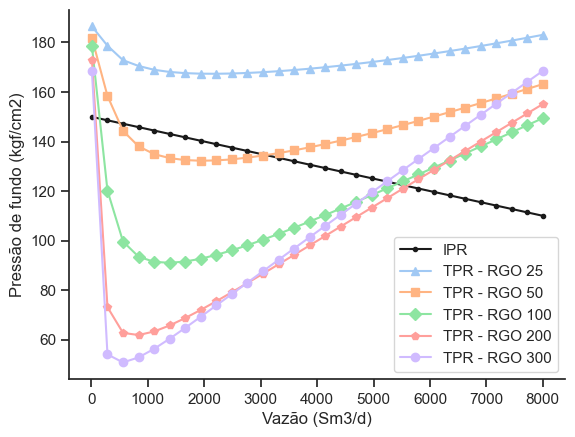

In [25]:
fig, ax = plt.subplots()

markers = ['^','s','D','p','o']

# plotando IPR
ax.plot(vazoes_eixo_x, pressoes_fundo_ipr, label='IPR', marker='.', c='k')

# plotando as várias TPR
for i in range(len(RGO)):
    ax.plot(vazoes_eixo_x, pressoes_fundo_tpr[i], label=f'TPR - RGO {RGO[i]}', marker=markers[i])

ax.set_xlabel('Vazão (Sm3/d)')
ax.set_ylabel('Pressão de fundo (kgf/cm2)');
ax.legend();

Observa-se que, no caso de RGO igual a 25, a curva TPR não intercepta a curva IPR, o que indica que o reservatório não é capaz de fornecer, no fundo do poço, a pressão necessária para sustentar qualquer vazão nessa condição. Dessa maneira, diz-se que o poço é não surgente e, portanto, métodos de elevação artificial devem ser utilizados. Por outro lado, para RGO igual a 100, o ponto de cruzamento estável ocorre em uma vazão significativamente maior em comparação ao caso base (RGO 50). Esse comportamento pode ser atribuído à redução na resistência ao escoamento, decorrente da menor massa específica média do fluido, o que reduz o termo hidrostático da perda de carga – o principal fator nesse cenário.

Entretanto, há um limite para o aumento do RGO. À medida que o RGO se eleva, o termo de fricção da perda de carga torna-se progressivamente mais relevante. Por isso, o ganho de produtividade na vazão de equilíbrio entre os casos de RGO 100 e RGO 200 é significativamente menor em relação ao incremento observado entre os casos de RGO 50 e RGO 100. Já no caso de RGO 300, observa-se uma inversão: a vazão de equilíbrio é inferior à registrada no caso de RGO 100.

Mesmo sem considerar a curva IPR, é possível perceber que, em altas vazões, as curvas tendem a se cruzar, resultando em uma inversão de tendência. Nessa região, RGOs mais elevados podem resultar em pressões de fundo mais altas (e, consequentemente, a maiores perdas de carga) para uma mesma vazão. Esse comportamento contrasta com o observado na região de baixas vazões, onde o termo hidrostático exerce maior influência e RGO's elevados resultam em menor perda de carga.

## Salvando o caso base

No comando abaixo, salvamos o caso base em um JSON para poder importá-lo no próximo tutorial.

In [26]:
caso_base.to_json('caso_base1_tutoriais')

## Faça você também!

**1**. Plote novos conjuntos de TPR como os da última figura que obtivemos, variando outros parâmetros, como diâmetro da linha, densidade do óleo ou fração de água.

**2**. Escolha algumas simulações que compõem as curvas TPR (você pode acessá-las na lista `casos`) e visualize os perfis ao longo do escoamento. Preste atenção nas diferenças para o caso base, em especial em altas vazões. Compare por exemplo os arranjos de fases e as magnitudes relativas dos termos de frição e hidrostática da perda de carga.